# Análise Climática do Brasil (2015–2024)

**Aluno(a):** Miguel Garcia Lopes do Amaral  
**Professor: Alexandre Neves Louzada** 
**Disciplina:** Linguagem de Programação  
**Turma:** Quinta/noite  

## 1. Introdução ao problema

O clima do Brasil varia bastante entre regiões, estados e épocas do ano. Compreender como temperatura, chuva, umidade, vento e eventos extremos se comportam ao longo do tempo é importante para identificar áreas mais expostas a riscos e apoiar o planejamento de ações de prevenção.

Este notebook desenvolve uma análise exploratória completa de uma base **simulada** de registros climáticos mensais, de janeiro de 2015 a dezembro de 2024, para 37 cidades brasileiras.

**Perguntas que a análise busca responder:**

1. Como estão distribuídas as variáveis climáticas e os níveis de alerta?
2. Existe tendência ou sazonalidade ao longo dos anos e dos meses?
3. Quais regiões, estados e cidades se destacam em temperatura, chuva e eventos extremos?
4. Quais variáveis se relacionam entre si?
5. O nível de alerta pode ser explicado pelas variáveis climáticas?

## 2. Explicação da base de dados

O projeto utiliza duas tabelas, armazenadas em arquivos CSV na pasta `dados/` e persistidas em um banco SQLite na pasta `database/`:

**Tabela `simulacao_clima_brasil.csv`** (4.440 registros, um por cidade e mês)

| Coluna | Descrição |
|---|---|
| `ano`, `mes`, `data` | Período do registro (a data é o primeiro dia do mês) |
| `regiao`, `uf`, `cidade` | Localização do registro |
| `temperatura_media`, `temperatura_maxima`, `temperatura_minima` | Temperaturas do mês, em °C |
| `chuva_mm` | Chuva acumulada no mês, em milímetros |
| `umidade` | Umidade relativa do ar, em % |
| `velocidade_vento` | Velocidade do vento |
| `eventos_extremos` | Quantidade de eventos extremos no mês |
| `nivel_alerta` | Nível de alerta: Baixo, Médio, Alto ou Crítico |

**Tabela `localidades.csv`** (37 cidades): `cidade`, `uf`, `regiao`, `latitude`, `longitude`. Foi criada para permitir análises geográficas e integrada à base principal pelo nome da cidade.

## 3. Leitura dos dados

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sqlalchemy import create_engine

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.2f}".format)

PASTA_IMAGENS = Path("../imagens")
PASTA_IMAGENS.mkdir(exist_ok=True)

In [2]:
clima = pd.read_csv("../dados/simulacao_clima_brasil.csv")
localidades = pd.read_csv("../dados/localidades.csv")

print("Base de clima:", clima.shape)
print("Tabela de localidades:", localidades.shape)
clima.head()

Base de clima: (4440, 14)
Tabela de localidades: (37, 5)


,ano,mes,data,regiao,uf,cidade,temperatura_media,temperatura_maxima,temperatura_minima,chuva_mm,umidade,velocidade_vento,eventos_extremos,nivel_alerta
0,2015,1,2015-01-01,Norte,AM,Manaus,27.90,34.70,22.50,16.30,42.80,31.50,1,Alto
1,2015,1,2015-01-01,Norte,PA,Belém,24.40,28.10,17.90,96.50,74.90,33.60,2,Médio
2,2015,1,2015-01-01,Norte,PA,Santarém,21.10,24.90,17.50,155.30,86.60,3.50,0,Crítico
3,2015,1,2015-01-01,Norte,RO,Porto Velho,25.50,29.70,21.30,137.50,89.30,16.70,1,Baixo
4,2015,1,2015-01-01,Norte,TO,Palmas,23.20,30.20,17.60,202.10,46.40,16.40,2,Médio


In [3]:
clima.info()

<class 'pandas.DataFrame'>
RangeIndex: 4440 entries, 0 to 4439
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ano                 4440 non-null   int64  
 1   mes                 4440 non-null   int64  
 2   data                4440 non-null   str    
 3   regiao              4440 non-null   str    
 4   uf                  4440 non-null   str    
 5   cidade              4440 non-null   str    
 6   temperatura_media   4440 non-null   float64
 7   temperatura_maxima  4440 non-null   float64
 8   temperatura_minima  4440 non-null   float64
 9   chuva_mm            4440 non-null   float64
 10  umidade             4440 non-null   float64
 11  velocidade_vento    4440 non-null   float64
 12  eventos_extremos    4440 non-null   int64  
 13  nivel_alerta        4440 non-null   str    
dtypes: float64(6), int64(3), str(5)
memory usage: 485.8 KB


In [4]:
localidades.head()

,cidade,uf,regiao,latitude,longitude
0,Brasília,DF,Centro-Oeste,-15.79,-47.88
1,Aparecida de Goiânia,GO,Centro-Oeste,-16.82,-49.25
2,Goiânia,GO,Centro-Oeste,-16.69,-49.26
3,Campo Grande,MS,Centro-Oeste,-20.47,-54.62
4,Cuiabá,MT,Centro-Oeste,-15.60,-56.10


In [5]:
engine = create_engine("sqlite:///../database/clima.db")

consulta = """
SELECT r.id, r.data, l.cidade, l.uf, l.regiao, r.temperatura_media, r.chuva_mm
FROM registros_clima r
INNER JOIN localidades l ON l.id = r.localidade_id
"""

amostra_banco = pd.read_sql(consulta, engine)
print("Registros lidos do banco SQLite:", len(amostra_banco))
amostra_banco.head()

Registros lidos do banco SQLite: 4440


,id,data,cidade,uf,regiao,temperatura_media,chuva_mm
0,1,2015-01-01,Manaus,AM,Norte,27.90,16.30
1,2,2015-01-01,Belém,PA,Norte,24.40,96.50
2,3,2015-01-01,Santarém,PA,Norte,21.10,155.30
3,4,2015-01-01,Porto Velho,RO,Norte,25.50,137.50
4,5,2015-01-01,Palmas,TO,Norte,23.20,202.10


## 4. Limpeza e preparação

Nesta etapa são verificados valores nulos, duplicados, tipos de dados, consistência entre as temperaturas e valores fora de faixas plausíveis.

In [6]:
print("Valores nulos por coluna:")
print(clima.isna().sum())
print("\nLinhas duplicadas:", clima.duplicated().sum())
print("\nTipos de dados:")
print(clima.dtypes)

Valores nulos por coluna:
ano                   0
mes                   0
data                  0
regiao                0
uf                    0
cidade                0
temperatura_media     0
temperatura_maxima    0
temperatura_minima    0
chuva_mm              0
umidade               0
velocidade_vento      0
eventos_extremos      0
nivel_alerta          0
dtype: int64

Linhas duplicadas: 0

Tipos de dados:
ano                     int64
mes                     int64
data                      str
regiao                    str
uf                        str
cidade                    str
temperatura_media     float64
temperatura_maxima    float64
temperatura_minima    float64
chuva_mm              float64
umidade               float64
velocidade_vento      float64
eventos_extremos        int64
nivel_alerta              str
dtype: object


In [7]:
clima["data"] = pd.to_datetime(clima["data"])
clima["regiao"] = clima["regiao"].str.strip()
clima["uf"] = clima["uf"].str.strip().str.upper()
clima["cidade"] = clima["cidade"].str.strip()
clima["nivel_alerta"] = clima["nivel_alerta"].str.strip()

inconsistentes = clima[
    (clima["temperatura_maxima"] < clima["temperatura_media"])
    | (clima["temperatura_media"] < clima["temperatura_minima"])
]

print("Registros com temperaturas inconsistentes:", len(inconsistentes))
print("Registros com chuva negativa:", (clima["chuva_mm"] < 0).sum())
print("Registros com umidade fora de 0 a 100:", (~clima["umidade"].between(0, 100)).sum())
print("Cidades sem correspondência em localidades:", (~clima["cidade"].isin(localidades["cidade"])).sum())
print("Período:", clima["data"].min().date(), "a", clima["data"].max().date())

Registros com temperaturas inconsistentes: 0
Registros com chuva negativa: 0
Registros com umidade fora de 0 a 100: 0
Cidades sem correspondência em localidades: 0
Período: 2015-01-01 a 2024-12-01


In [8]:
colunas_numericas = [
    "temperatura_media",
    "temperatura_maxima",
    "temperatura_minima",
    "chuva_mm",
    "umidade",
    "velocidade_vento",
    "eventos_extremos",
]

q1 = clima[colunas_numericas].quantile(0.25)
q3 = clima[colunas_numericas].quantile(0.75)
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

outliers = (
    (clima[colunas_numericas] < limite_inferior)
    | (clima[colunas_numericas] > limite_superior)
).sum()

outliers.to_frame("Quantidade de outliers (IQR)")

,Quantidade de outliers (IQR)
temperatura_media,33
temperatura_maxima,37
temperatura_minima,41
chuva_mm,94
umidade,0
velocidade_vento,0
eventos_extremos,23


**Decisões de limpeza:** a base não possui valores nulos nem linhas duplicadas, as temperaturas são consistentes (máxima ≥ média ≥ mínima) e todas as cidades possuem coordenadas. Os valores identificados como outliers pelo critério do intervalo interquartil foram **mantidos**, pois representam situações extremas do clima, que são justamente o foco da análise.

## 5. Engenharia de atributos

In [9]:
ordem_alerta = ["Baixo", "Médio", "Alto", "Crítico"]
mapa_alerta = {nivel: indice + 1 for indice, nivel in enumerate(ordem_alerta)}

estacoes = {
    12: "Verão", 1: "Verão", 2: "Verão",
    3: "Outono", 4: "Outono", 5: "Outono",
    6: "Inverno", 7: "Inverno", 8: "Inverno",
    9: "Primavera", 10: "Primavera", 11: "Primavera",
}

clima = clima.merge(localidades[["cidade", "latitude", "longitude"]], on="cidade", how="left")

clima["amplitude_termica"] = clima["temperatura_maxima"] - clima["temperatura_minima"]
clima["estacao"] = clima["mes"].map(estacoes)
clima["alerta_num"] = clima["nivel_alerta"].map(mapa_alerta)
clima["alerta_alto_critico"] = clima["alerta_num"] >= 3

print("Coordenadas ausentes:", clima[["latitude", "longitude"]].isna().sum().sum())
clima[["data", "cidade", "amplitude_termica", "estacao", "alerta_num", "alerta_alto_critico"]].head()

Coordenadas ausentes: 0


,data,cidade,amplitude_termica,estacao,alerta_num,alerta_alto_critico
0,2015-01-01,Manaus,12.20,Verão,3,True
1,2015-01-01,Belém,10.20,Verão,2,False
2,2015-01-01,Santarém,7.40,Verão,4,True
3,2015-01-01,Porto Velho,8.40,Verão,1,False
4,2015-01-01,Palmas,12.60,Verão,2,False


Atributos criados: `amplitude_termica` (diferença entre a temperatura máxima e a mínima), `estacao` (estação do ano no hemisfério sul), `alerta_num` (nível de alerta codificado de 1 a 4), `alerta_alto_critico` (indicador de alerta Alto ou Crítico) e as coordenadas geográficas, obtidas pela integração com a tabela `localidades`.

## 6. Análise exploratória

In [10]:
variaveis = colunas_numericas + ["amplitude_termica"]
clima[variaveis].describe().T

,count,mean,std,min,25%,50%,75%,max
temperatura_media,4440.00,24.99,3.92,11.40,22.40,25.00,27.60,39.30
temperatura_maxima,4440.00,30.50,4.18,15.60,27.70,30.40,33.20,45.40
temperatura_minima,4440.00,19.97,4.11,5.70,17.30,19.95,22.70,34.30
chuva_mm,4440.00,105.90,60.04,4.20,61.50,94.80,140.50,491.50
umidade,4440.00,66.41,18.27,35.00,50.30,66.55,82.00,97.90
velocidade_vento,4440.00,18.39,9.69,2.00,10.00,18.60,26.90,35.00
eventos_extremos,4440.00,2.01,1.43,0.00,1.00,2.00,3.00,9.00
amplitude_termica,4440.00,10.52,1.85,6.10,9.10,10.50,11.90,14.90


In [11]:
distribuicao_alerta = clima["nivel_alerta"].value_counts().reindex(ordem_alerta)
pd.DataFrame(
    {
        "Registros": distribuicao_alerta,
        "Percentual (%)": distribuicao_alerta / len(clima) * 100,
    }
)

,Registros,Percentual (%)
nivel_alerta,,
Baixo,1156,26.04
Médio,1121,25.25
Alto,1068,24.05
Crítico,1095,24.66


In [12]:
clima.groupby("regiao")[
    ["temperatura_media", "chuva_mm", "umidade", "velocidade_vento", "eventos_extremos", "amplitude_termica"]
].mean()

,temperatura_media,chuva_mm,umidade,velocidade_vento,eventos_extremos,amplitude_termica
regiao,,,,,,
Centro-Oeste,25.09,106.61,65.42,17.97,2.13,10.46
Nordeste,24.88,110.14,66.62,18.67,2.06,10.55
Norte,25.00,103.31,66.18,18.23,1.90,10.51
Sudeste,24.97,103.97,66.45,18.47,1.97,10.49
Sul,25.11,105.97,67.08,18.36,2.03,10.63


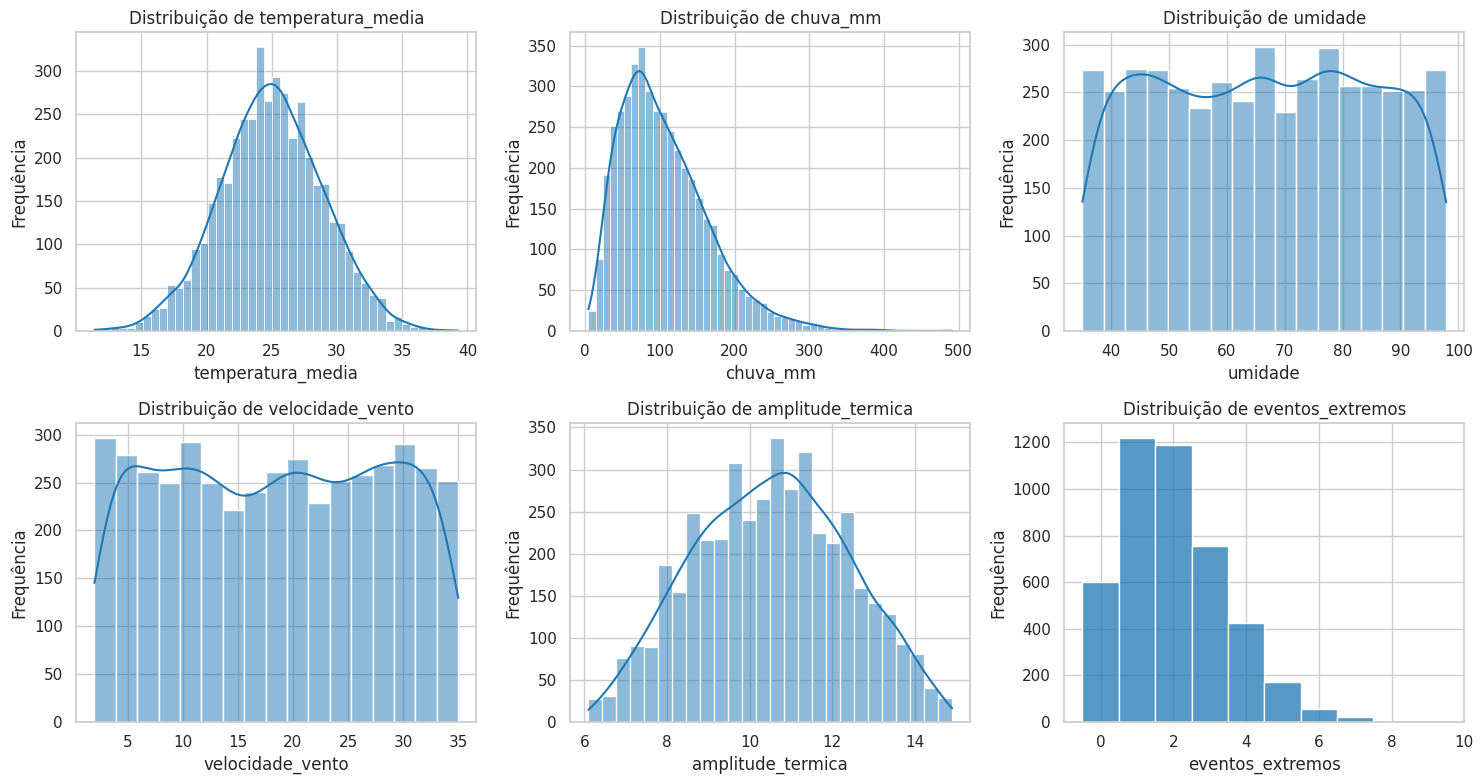

In [13]:
variaveis_hist = [
    "temperatura_media",
    "chuva_mm",
    "umidade",
    "velocidade_vento",
    "amplitude_termica",
    "eventos_extremos",
]

fig, eixos = plt.subplots(2, 3, figsize=(15, 8))
for eixo, variavel in zip(eixos.ravel(), variaveis_hist):
    sns.histplot(
        clima[variavel],
        kde=variavel != "eventos_extremos",
        discrete=variavel == "eventos_extremos",
        color="#1f77b4",
        ax=eixo,
    )
    eixo.set_title(f"Distribuição de {variavel}")
    eixo.set_xlabel(variavel)
    eixo.set_ylabel("Frequência")
plt.tight_layout()
plt.savefig(PASTA_IMAGENS / "distribuicoes.png", dpi=130, bbox_inches="tight")
plt.show()

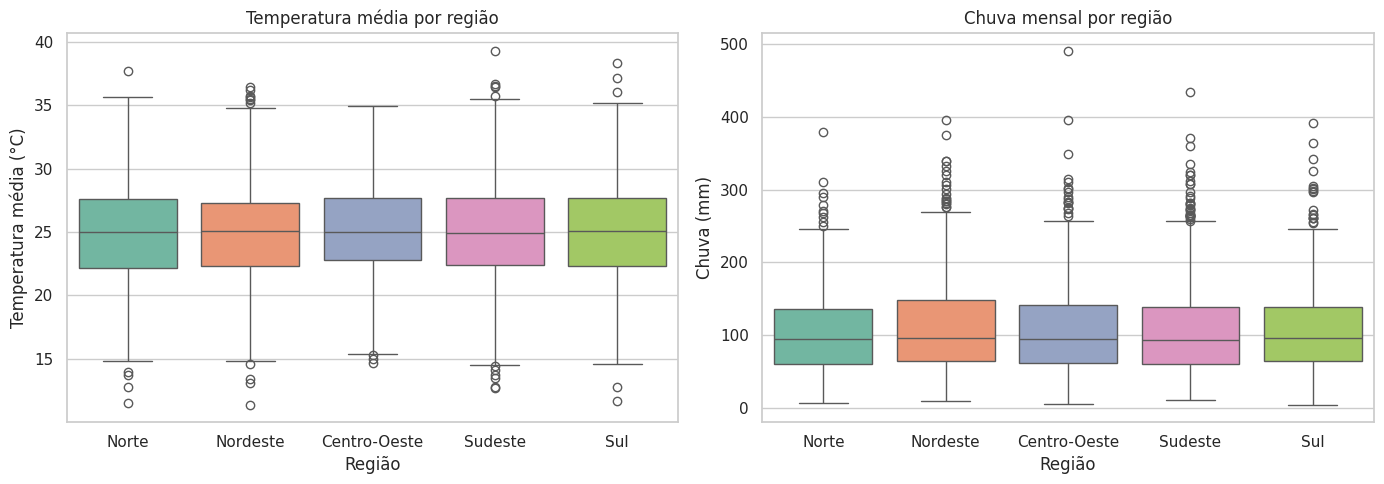

In [14]:
fig, eixos = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=clima, x="regiao", y="temperatura_media", hue="regiao", palette="Set2", legend=False, ax=eixos[0])
eixos[0].set_title("Temperatura média por região")
eixos[0].set_xlabel("Região")
eixos[0].set_ylabel("Temperatura média (°C)")
sns.boxplot(data=clima, x="regiao", y="chuva_mm", hue="regiao", palette="Set2", legend=False, ax=eixos[1])
eixos[1].set_title("Chuva mensal por região")
eixos[1].set_xlabel("Região")
eixos[1].set_ylabel("Chuva (mm)")
plt.tight_layout()
plt.savefig(PASTA_IMAGENS / "boxplot_regioes.png", dpi=130, bbox_inches="tight")
plt.show()

## 7. KPIs

In [15]:
kpis = pd.DataFrame(
    {
        "Indicador": [
            "Temperatura média (°C)",
            "Chuva média mensal (mm)",
            "Umidade média (%)",
            "Amplitude térmica média (°C)",
            "Eventos extremos (total)",
            "Eventos extremos por cidade/mês",
            "Alertas Alto ou Crítico (%)",
            "Registros analisados",
        ],
        "Valor": [
            clima["temperatura_media"].mean(),
            clima["chuva_mm"].mean(),
            clima["umidade"].mean(),
            clima["amplitude_termica"].mean(),
            clima["eventos_extremos"].sum(),
            clima["eventos_extremos"].mean(),
            clima["alerta_alto_critico"].mean() * 100,
            len(clima),
        ],
    }
)
kpis

,Indicador,Valor
0,Temperatura média (°C),24.99
1,Chuva média mensal (mm),105.90
2,Umidade média (%),66.41
3,Amplitude térmica média (°C),10.52
4,Eventos extremos (total),8918.00
5,Eventos extremos por cidade/mês,2.01
6,Alertas Alto ou Crítico (%),48.72
7,Registros analisados,4440.00


In [16]:
ranking_cidades = (
    clima.groupby(["cidade", "uf", "regiao"], as_index=False)
    .agg(
        temperatura_media=("temperatura_media", "mean"),
        chuva_media=("chuva_mm", "mean"),
        eventos_total=("eventos_extremos", "sum"),
        pct_alerta_alto_critico=("alerta_alto_critico", "mean"),
    )
)
ranking_cidades["pct_alerta_alto_critico"] = ranking_cidades["pct_alerta_alto_critico"] * 100

print("Cidades com mais eventos extremos:")
print(ranking_cidades.sort_values("eventos_total", ascending=False).head(5).to_string(index=False))
print("\nCidades com maior temperatura média:")
print(ranking_cidades.sort_values("temperatura_media", ascending=False).head(5).to_string(index=False))
print("\nCidades com menor temperatura média:")
print(ranking_cidades.sort_values("temperatura_media").head(5).to_string(index=False))

Cidades com mais eventos extremos:
      cidade uf       regiao  temperatura_media  chuva_media  eventos_total  pct_alerta_alto_critico
Campo Grande MS Centro-Oeste              25.24       103.12            284                    50.83
      Cuiabá MT Centro-Oeste              25.12        95.93            265                    47.50
Porto Alegre RS          Sul              25.25       107.18            263                    50.00
    Salvador BA     Nordeste              25.18       106.14            261                    51.67
    Londrina PR          Sul              25.11       102.14            255                    55.83

Cidades com maior temperatura média:
        cidade uf  regiao  temperatura_media  chuva_media  eventos_total  pct_alerta_alto_critico
    Vila Velha ES Sudeste              25.55        99.64            242                    50.00
      Curitiba PR     Sul              25.45       113.59            231                    52.50
 Caxias do Sul RS     Sul  

## 8. Gráficos

Variação estimada pela tendência linear: +0.023 °C por ano
Variação estimada em dez anos: +0.23 °C


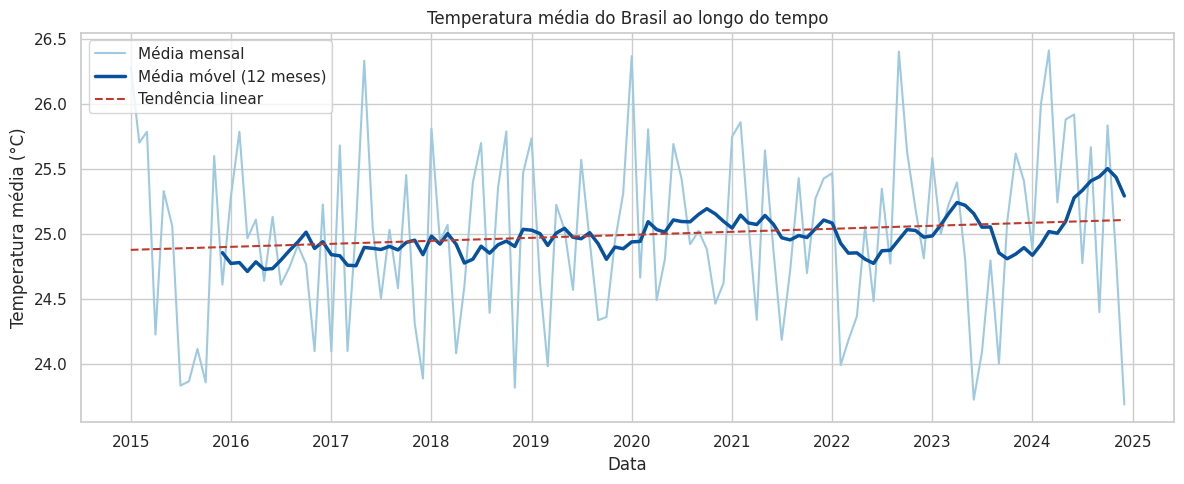

In [17]:
serie = clima.groupby("data")["temperatura_media"].mean()
media_movel = serie.rolling(12).mean()
x = np.arange(len(serie))
coeficientes = np.polyfit(x, serie.values, 1)
tendencia = np.polyval(coeficientes, x)

fig, eixo = plt.subplots(figsize=(12, 5))
eixo.plot(serie.index, serie.values, color="#9ecae1", label="Média mensal")
eixo.plot(serie.index, media_movel.values, color="#08519c", linewidth=2.5, label="Média móvel (12 meses)")
eixo.plot(serie.index, tendencia, color="#c0392b", linestyle="--", label="Tendência linear")
eixo.set_title("Temperatura média do Brasil ao longo do tempo")
eixo.set_xlabel("Data")
eixo.set_ylabel("Temperatura média (°C)")
eixo.legend()
plt.tight_layout()
plt.savefig(PASTA_IMAGENS / "serie_temporal.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"Variação estimada pela tendência linear: {coeficientes[0] * 12:+.3f} °C por ano")
print(f"Variação estimada em dez anos: {coeficientes[0] * 120:+.2f} °C")

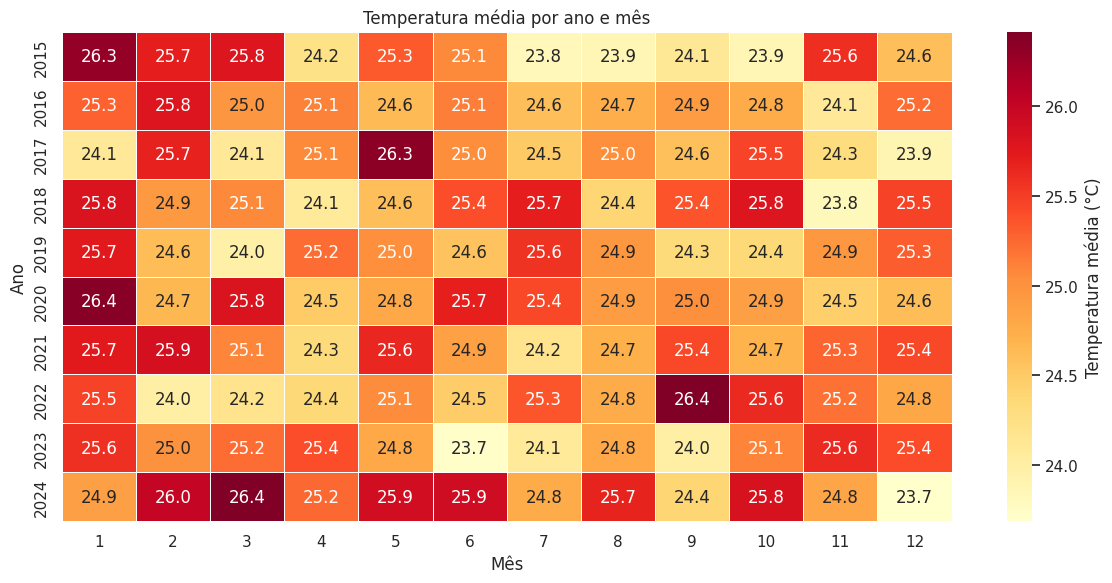

In [18]:
pivo = clima.pivot_table(index="ano", columns="mes", values="temperatura_media", aggfunc="mean")

fig, eixo = plt.subplots(figsize=(12, 6))
sns.heatmap(
    pivo,
    cmap="YlOrRd",
    annot=True,
    fmt=".1f",
    linewidths=0.4,
    cbar_kws={"label": "Temperatura média (°C)"},
    ax=eixo,
)
eixo.set_title("Temperatura média por ano e mês")
eixo.set_xlabel("Mês")
eixo.set_ylabel("Ano")
plt.tight_layout()
plt.savefig(PASTA_IMAGENS / "heatmap_ano_mes.png", dpi=130, bbox_inches="tight")
plt.show()

In [19]:
sazonalidade = clima.groupby("mes")[["temperatura_media", "chuva_mm", "eventos_extremos"]].mean()
sazonalidade

,temperatura_media,chuva_mm,eventos_extremos
mes,,,
1,25.53,104.55,1.92
2,25.22,105.04,1.98
3,25.06,110.80,1.95
4,24.75,107.15,2.06
5,25.21,109.02,1.98
6,24.99,105.22,2.02
7,24.80,107.53,1.98
8,24.79,107.13,2.14
9,24.86,103.30,2.02


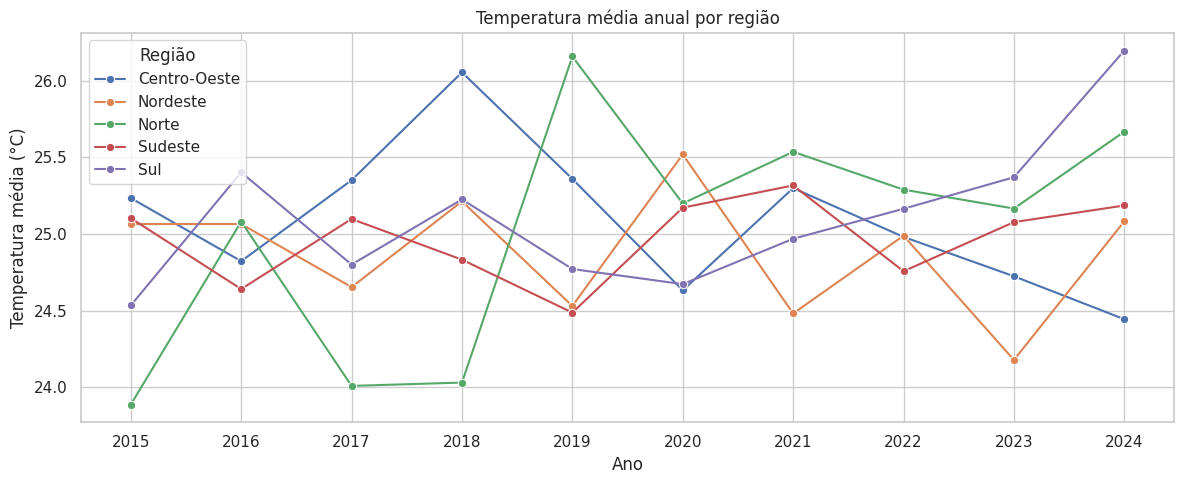

In [20]:
anual = clima.groupby(["ano", "regiao"], as_index=False)["temperatura_media"].mean()

fig, eixo = plt.subplots(figsize=(12, 5))
sns.lineplot(data=anual, x="ano", y="temperatura_media", hue="regiao", marker="o", ax=eixo)
eixo.set_title("Temperatura média anual por região")
eixo.set_xlabel("Ano")
eixo.set_ylabel("Temperatura média (°C)")
eixo.set_xticks(sorted(clima["ano"].unique()))
eixo.legend(title="Região")
plt.tight_layout()
plt.savefig(PASTA_IMAGENS / "temperatura_anual_regiao.png", dpi=130, bbox_inches="tight")
plt.show()

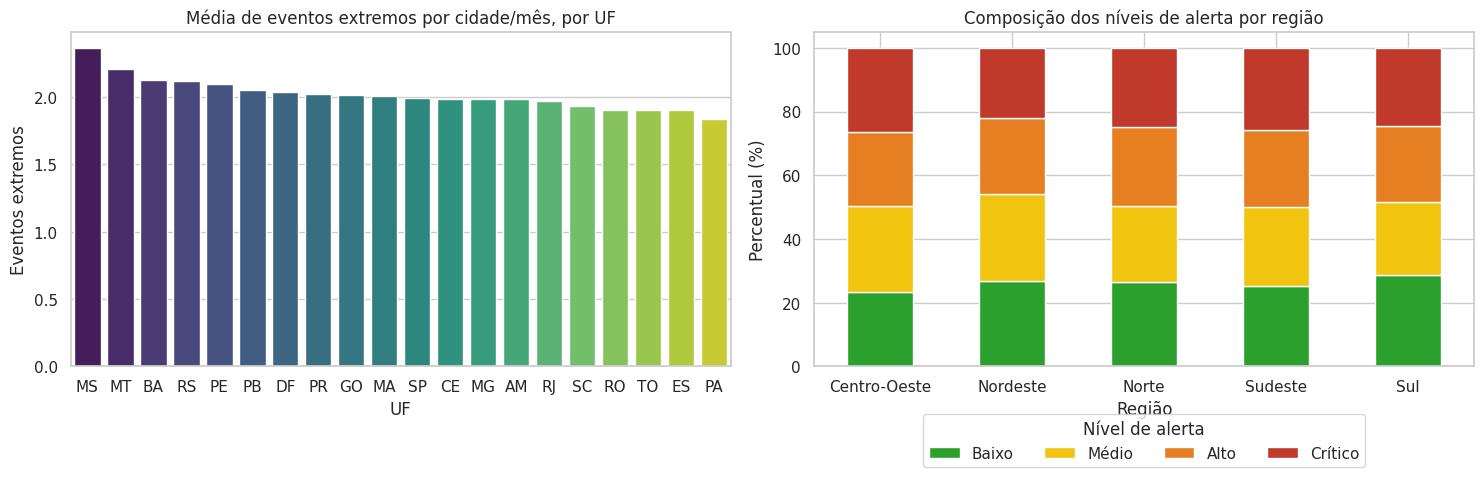

In [21]:
eventos_uf = (
    clima.groupby("uf", as_index=False)["eventos_extremos"]
    .mean()
    .sort_values("eventos_extremos", ascending=False)
)

cores_alerta = {"Baixo": "#2ca02c", "Médio": "#f1c40f", "Alto": "#e67e22", "Crítico": "#c0392b"}
alerta_regiao = (
    pd.crosstab(clima["regiao"], clima["nivel_alerta"], normalize="index")
    .reindex(columns=ordem_alerta)
    * 100
)

fig, eixos = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=eventos_uf, x="uf", y="eventos_extremos", hue="uf", palette="viridis", legend=False, ax=eixos[0])
eixos[0].set_title("Média de eventos extremos por cidade/mês, por UF")
eixos[0].set_xlabel("UF")
eixos[0].set_ylabel("Eventos extremos")
alerta_regiao.plot(kind="bar", stacked=True, color=[cores_alerta[n] for n in ordem_alerta], ax=eixos[1])
eixos[1].set_title("Composição dos níveis de alerta por região")
eixos[1].set_xlabel("Região")
eixos[1].set_ylabel("Percentual (%)")
eixos[1].tick_params(axis="x", rotation=0)
eixos[1].legend(title="Nível de alerta", loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=4)
plt.tight_layout()
plt.savefig(PASTA_IMAGENS / "comparativos.png", dpi=130, bbox_inches="tight")
plt.show()

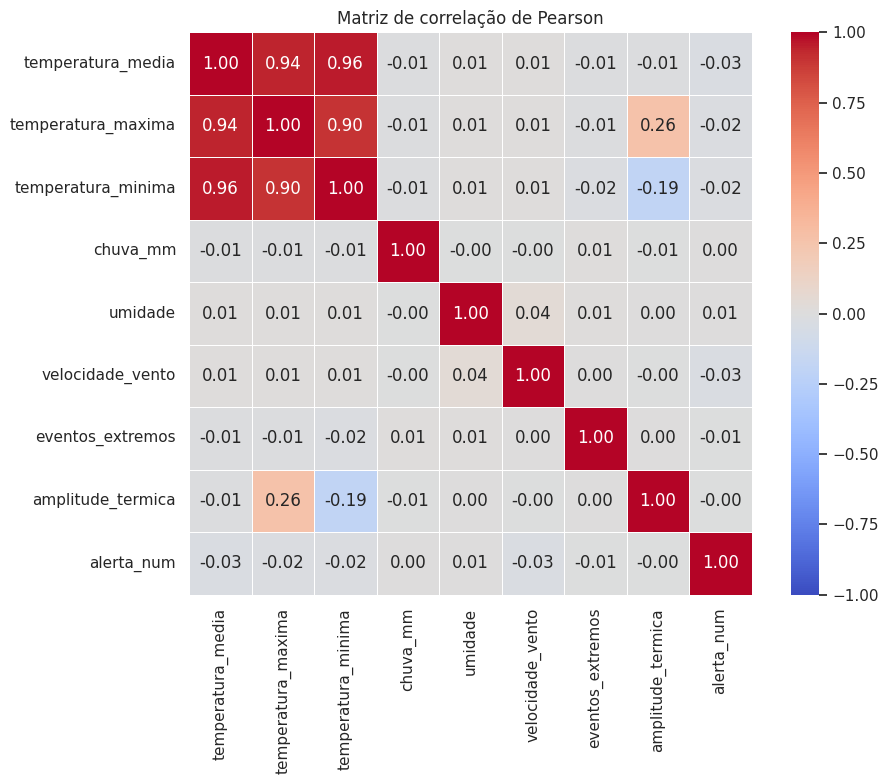

In [22]:
colunas_corr = variaveis + ["alerta_num"]
matriz_corr = clima[colunas_corr].corr(method="pearson")

fig, eixo = plt.subplots(figsize=(10, 8))
sns.heatmap(
    matriz_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    ax=eixo,
)
eixo.set_title("Matriz de correlação de Pearson")
plt.tight_layout()
plt.savefig(PASTA_IMAGENS / "correlacao.png", dpi=130, bbox_inches="tight")
plt.show()

In [23]:
variaveis_temperatura = {"temperatura_media", "temperatura_maxima", "temperatura_minima", "amplitude_termica"}

pares = []
for i, a in enumerate(colunas_corr):
    for b in colunas_corr[i + 1:]:
        pares.append(
            {
                "variavel_a": a,
                "variavel_b": b,
                "correlacao": matriz_corr.loc[a, b],
                "entre_temperaturas": a in variaveis_temperatura and b in variaveis_temperatura,
            }
        )

tabela_pares = pd.DataFrame(pares).sort_values("correlacao", key=lambda s: s.abs(), ascending=False)
print("Maiores correlações (todas as variáveis):")
print(tabela_pares.head(6).to_string(index=False))
print("\nMaiores correlações fora do grupo das temperaturas:")
print(tabela_pares[~tabela_pares["entre_temperaturas"]].head(5).to_string(index=False))

Maiores correlações (todas as variáveis):
        variavel_a         variavel_b  correlacao  entre_temperaturas
 temperatura_media temperatura_minima        0.96                True
 temperatura_media temperatura_maxima        0.94                True
temperatura_maxima temperatura_minima        0.90                True
temperatura_maxima  amplitude_termica        0.26                True
temperatura_minima  amplitude_termica       -0.19                True
           umidade   velocidade_vento        0.04               False

Maiores correlações fora do grupo das temperaturas:
        variavel_a       variavel_b  correlacao  entre_temperaturas
           umidade velocidade_vento        0.04               False
 temperatura_media       alerta_num       -0.03               False
  velocidade_vento       alerta_num       -0.03               False
temperatura_maxima       alerta_num       -0.02               False
temperatura_minima       alerta_num       -0.02               False


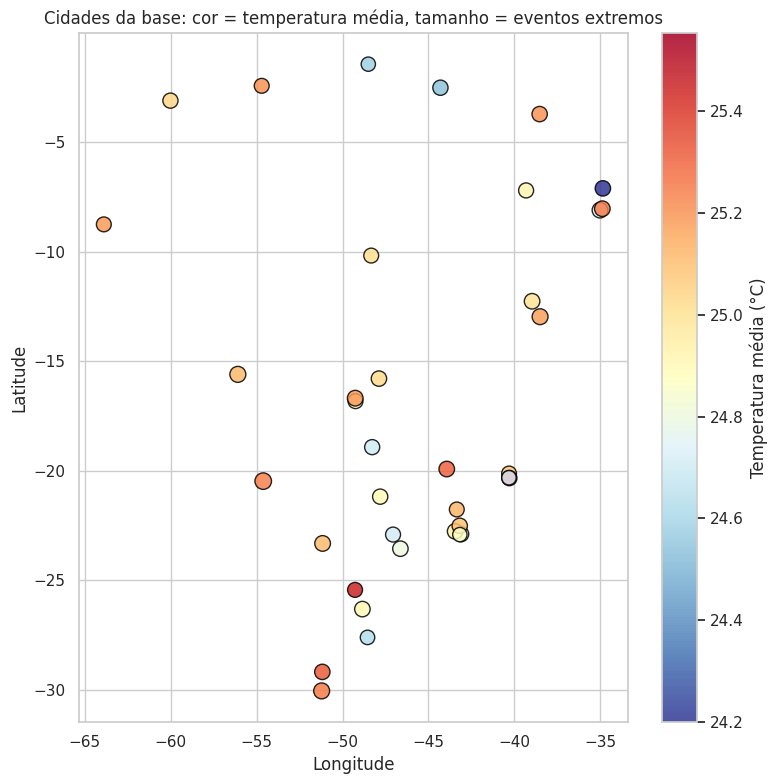

In [24]:
cidades = clima.groupby(["cidade", "uf", "regiao", "latitude", "longitude"], as_index=False).agg(
    temperatura_media=("temperatura_media", "mean"),
    eventos_total=("eventos_extremos", "sum"),
)

fig, eixo = plt.subplots(figsize=(8, 8))
pontos = eixo.scatter(
    cidades["longitude"],
    cidades["latitude"],
    c=cidades["temperatura_media"],
    s=cidades["eventos_total"] / 2,
    cmap="RdYlBu_r",
    edgecolor="black",
    alpha=0.85,
)
plt.colorbar(pontos, ax=eixo, label="Temperatura média (°C)")
eixo.set_title("Cidades da base: cor = temperatura média, tamanho = eventos extremos")
eixo.set_xlabel("Longitude")
eixo.set_ylabel("Latitude")
plt.tight_layout()
plt.savefig(PASTA_IMAGENS / "mapa_cidades.png", dpi=130, bbox_inches="tight")
plt.show()

## 9. Interpretação dos resultados

**Distribuições.** A temperatura média tem média de 24,99 °C e mediana de 25,00 °C, com desvio padrão de 3,92 °C, o que indica distribuição simétrica. A chuva mensal é assimétrica à direita (média de 105,9 mm, mediana de 94,8 mm e máximo de 491,5 mm): a maioria dos meses tem chuva moderada e poucos meses têm volumes muito altos. Umidade e velocidade do vento se espalham de forma uniforme por toda a faixa observada.

**Nível de alerta.** Os quatro níveis aparecem em proporções semelhantes (entre 24 % e 26 % dos registros cada), e 48,7 % dos registros estão em alerta Alto ou Crítico. A composição dos níveis também é parecida entre as regiões (de 45,9 % no Nordeste a 50,0 % no Sudeste em alertas Alto ou Crítico).

**Análise temporal.** A tendência linear da temperatura média nacional é de +0,023 °C por ano (cerca de +0,23 °C em dez anos), uma variação muito pequena diante do desvio padrão de 3,92 °C. Entre os anos, a média varia de 24,84 °C (2017) a 25,29 °C (2024). Não há sazonalidade marcante: a média mensal de temperatura fica entre 24,75 °C (abril) e 25,53 °C (janeiro), e a chuva entre 102,3 mm (novembro) e 110,8 mm (março).

**Comparativos.** Entre as regiões, a temperatura média vai de 24,88 °C (Nordeste) a 25,11 °C (Sul), uma diferença de apenas 0,23 °C. O Nordeste tem a maior chuva média (110,1 mm) e o Norte a menor (103,3 mm). Em eventos extremos por cidade/mês, o Centro-Oeste lidera (2,13) e o Norte tem a menor média (1,90). Por UF, MS (2,37), MT (2,21) e BA (2,13) têm as maiores médias. Entre as cidades, Campo Grande (MS) acumula mais eventos extremos (284), Vila Velha (ES) tem a maior temperatura média (25,55 °C) e João Pessoa (PB) a menor (24,20 °C).

**Correlações.** As temperaturas média, máxima e mínima são fortemente correlacionadas entre si (r entre 0,90 e 0,96), o que é esperado, pois uma deriva das outras. Fora desse grupo, nenhuma correlação passa de |0,04|: chuva, umidade, vento e eventos extremos praticamente não se relacionam. O nível de alerta também tem correlação desprezível com todas as variáveis climáticas (|r| ≤ 0,03).

**Análise geográfica.** O mapa mostra as 37 cidades distribuídas por todo o país, mas as diferenças de temperatura média e de eventos extremos entre elas são pequenas, sem um padrão espacial claro (por exemplo, não há gradiente entre Norte e Sul).

## 10. Conclusão

O projeto percorreu o fluxo completo de análise de dados: leitura e integração das tabelas (CSV e banco SQLite), limpeza, engenharia de atributos, análise exploratória, cálculo de KPIs e visualizações com Pandas, Matplotlib e Seaborn.

Os principais resultados são: temperatura média nacional de 24,99 °C, chuva média mensal de 105,9 mm, 8.918 eventos extremos registrados no período (média de 2,01 por cidade/mês) e 48,7 % dos registros em alerta Alto ou Crítico. Há uma leve tendência de aumento da temperatura (+0,023 °C por ano), mas muito pequena para ser considerada relevante.

A principal constatação é que a base praticamente não apresenta padrões: não há sazonalidade clara, as diferenças entre regiões são pequenas, as variáveis climáticas quase não se correlacionam e o nível de alerta não é explicado por nenhuma delas. Isso é típico de dados **simulados de forma aleatória**. Portanto, os resultados servem para demonstrar o método analítico e **não devem ser usados como diagnóstico climático real**.

**Limitações:** base simulada, sem a definição do critério usado para o nível de alerta e com coordenadas aproximadas das cidades.

**Próximos passos:** substituir a base por dados observados (por exemplo, de estações meteorológicas), definir um critério explícito para o nível de alerta e testar modelos para prever eventos extremos.

O dashboard interativo com os mesmos indicadores está disponível no aplicativo Streamlit do projeto: https://projeto-de-an-lise-e-visualiza-o-de-dados-com-python-csmtmsyuf.streamlit.app/.